# 3주차 코드 과제: 순전파·역전파와 Optimizer

이번 과제에서는 NumPy로 구성된 MLP의 핵심 연산을 직접 완성하고,  
SGD·Momentum·AdaGrad의 학습 곡선을 비교합니다.

## 진행 순서

1. `#채워주세요`로 표시된 부분을 모두 완성합니다.
2. **런타임 → 모두 실행**으로 위에서부터 오류 없이 실행되는지 확인합니다.
3. 세 optimizer의 train loss 그래프를 비교하고 마지막 질문에 답합니다.
4. 실행 결과가 남아 있는 노트북을 제출합니다.

## 제출 안내

- 권장 환경: Google Colab 또는 Jupyter Notebook
- 제출 파일명: `3주차 과제2_기수_이름.ipynb`
- 첫 번째 과제인 Sigmoid 계산 그래프는 안내된 형식의 스크린샷으로 별도 제출합니다.


In [1]:
import numpy as np

SEED = 42
np.random.seed(SEED)


#Define network

순전파와 역전파가 어떻게 구현되는지 확인해보세요!

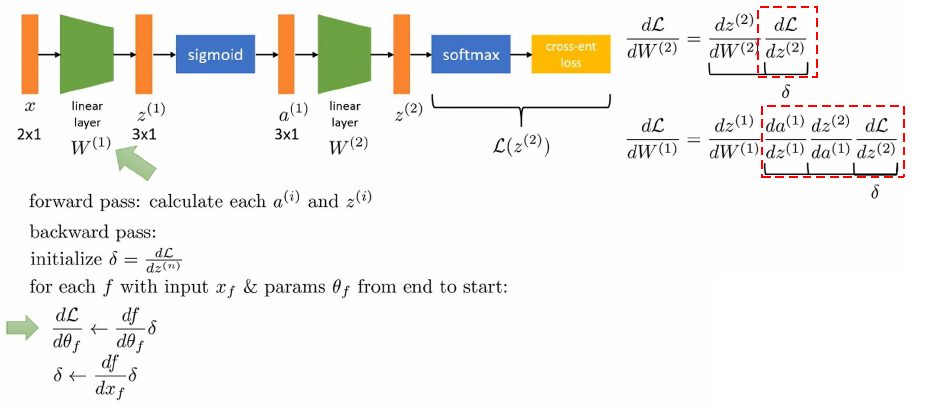

In [2]:
from collections import OrderedDict

class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std = 0.01):
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

        self.layers = OrderedDict()
        self.layers['Affine1'] = Affine(self.params['W1'], self.params['b1'])
        self.layers['Relu1'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W2'], self.params['b2'])

        self.lastLayer = SoftmaxWithLoss()


    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    # forward
    def loss(self, x, t):
        y = self.predict(x)
        return self.lastLayer.forward(y, t)


    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def gradient(self, x, t):
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.lastLayer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        grads = {}
        grads['W1'], grads['b1'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W2'], grads['b2'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads

#Layers

각 레이어에는 init, forward, backward 함수가 정의되어 있습니다.

In [3]:
class Affine:
    def __init__(self, W, b):
        self.W =W
        self.b = b

        self.x = None
        self.original_x_shape = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.original_x_shape = x.shape
        x = x.reshape(x.shape[0], -1)
        self.x = x

        out = np.dot(x, self.W) + self.b            # " z = xW + b " 수식 그대로의 원리

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)

        # 계산 그래프를 직접 그려보세요(권장)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)

        dx = dx.reshape(*self.original_x_shape)
        return dx

In [4]:
class Relu:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0

        return out

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx

In [5]:
class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None
        self.t = None

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)

        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        if self.t.size == self.y.size:
            dx = (self.y - self.t) / batch_size
        else:
            dx = self.y.copy()
            dx[np.arange(batch_size), self.t] -= 1
            dx = dx / batch_size

        return dx

#Functions

복습차원에서 빈칸을 채워봅시다!

In [6]:
def softmax(x):
    '''
    x: n x num_class
    '''
    # 계산 안정성 추가
    x = x - np.max(x, axis=-1, keepdims=True)
    return np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)

In [7]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

#Optimizers

파라미터와 기울기를 인수로 받아서 파라미터를 갱신합니다.

SGD는 파라미터를 업데이트할 때, 각 반복마다 계산된 **기울기(gradient)**를 이용하여 파라미터를 업데이트합니다.

$$
\theta_{t+1} = \theta_t - \eta \nabla_\theta J(\theta_t)
$$

- $\theta_t$ : 파라미터  
- $\eta$ : 학습률(learning rate)  
- $\nabla_\theta J(\theta_t)$ : 파라미터에 대한 손실 함수의 기울기(gradient)  

In [8]:
class SGD:

    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

Momentum은 이전 기울기를 반영하여 학습을 가속화하는 방법입니다.

$$
v_{t+1} = \alpha v_t - \eta \nabla_\theta J(\theta_t)
$$
$$
\theta_{t+1} = \theta_t + v_{t+1}
$$

- $ v_t $ : 이전 기울기 업데이트
- $ \alpha $ : 모멘텀 하이퍼파라미터 (0 < $ \alpha $ < 1)
- $ \nabla_\theta J(\theta_t) $ : 현재 기울기
- $ \eta $ : 학습률

In [9]:
class Momentum:

    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)

        for key in params.keys():
            self.v[key] = self.momentum * self.v[key] - self.lr * grads[key]
            params[key] += self.v[key]

Adagrad는 학습이 진행될수록 각 파라미터의 학습률이 감소합니다.

$$
G_t = G_{t-1} + \nabla_\theta J(\theta_t)^2
$$
$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t + \epsilon}} \nabla_\theta J(\theta_t)
$$

- $ G_t $ : 기울기의 제곱 합(누적)
- $ \epsilon $ : 작은 값 (수치 안정성 보장)
- $ \eta $ : 학습률
- $ \nabla_\theta J(\theta_t) $ : 현재 기울기

In [10]:
class AdaGrad:

    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

## 구현 확인

아래 셀은 앞에서 구현한 함수와 레이어의 기본 동작을 확인합니다.  
`기본 구현 확인 완료`가 출력된 뒤 학습 단계로 넘어가세요.


In [11]:
def run_basic_checks():
    sample = np.array([[1.0, -2.0, 0.5], [0.0, 1.5, -0.5]])

    probabilities = softmax(sample)
    assert probabilities.shape == sample.shape
    assert np.allclose(probabilities.sum(axis=1), 1.0)

    targets = np.eye(3)[[0, 1]]
    loss = cross_entropy_error(probabilities, targets)
    assert np.isscalar(loss) and np.isfinite(loss)

    affine = Affine(np.ones((3, 2)), np.zeros(2))
    affine_output = affine.forward(sample)
    assert affine_output.shape == (2, 2)
    assert affine.backward(np.ones_like(affine_output)).shape == sample.shape

    relu = Relu()
    relu_output = relu.forward(np.array([[-1.0, 0.0, 2.0]]))
    assert np.array_equal(relu_output, np.array([[0.0, 0.0, 2.0]]))
    assert relu.backward(np.ones_like(relu_output)).shape == relu_output.shape

    print("기본 구현 확인 완료")


run_basic_checks()


기본 구현 확인 완료


#Training

**MNIST 손글씨 dataset**

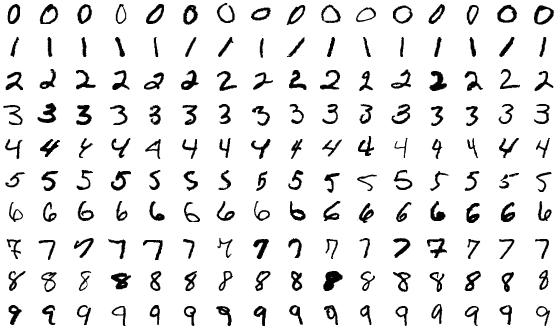

In [12]:
from torchvision import datasets

# MNIST load
mnist_train = datasets.MNIST(root='./data', train=True, download=True)
mnist_test  = datasets.MNIST(root='./data', train=False, download=True)


# flatten(28*28), normalization(0~1)
x_train = mnist_train.data.view(-1, 28 * 28).numpy().astype('float32') / 255.0
t_train = mnist_train.targets.numpy()
x_test  = mnist_test.data.view(-1, 28 * 28).numpy().astype('float32') / 255.0
t_test  = mnist_test.targets.numpy()

# one-hot encoding
n = len(np.unique(t_train))  # 보통 10
t_train = np.eye(n)[t_train]
t_test  = np.eye(n)[t_test]

print(f'x_train.shape: {x_train.shape}')  # (60000, 784)
print(f't_train.shape: {t_train.shape}')  # (60000, 10)
print(f'x_test.shape:  {x_test.shape}')   # (10000, 784)
print(f't_test.shape:  {t_test.shape}')   # (10000, 10)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.97MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.06MB/s]


x_train.shape: (60000, 784)
t_train.shape: (60000, 10)
x_test.shape:  (10000, 784)
t_test.shape:  (10000, 10)


https://docs.pytorch.org/vision/stable/datasets.html

MNIST말고도 다양한 데이터셋이 있습니다 :)

## 실험 과제

1. `batch_size`, `learning_rate`, `hidden_size`, `iters_num` 중 하나 이상을 바꿔보세요.
2. SGD, Momentum, AdaGrad의 train loss 그래프를 비교하세요.
3. 마지막 셀에 각 optimizer의 특징과 그래프에서 관찰한 차이를 작성하세요.


In [13]:
# 기본 설정은 optimizer마다 2 epoch씩 학습합니다.
iters_num = 1200
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 1e-2

optimizer_classes = {
    "sgd": SGD,
    "momentum": Momentum,
    "adagrad": AdaGrad,
}
train_loss_list = {name: [] for name in optimizer_classes}
iter_per_epoch = max(train_size // batch_size, 1)


for name, optimizer_class in optimizer_classes.items():
    print(f"\n====== Training with {name.upper()} optimizer ======")

    # 같은 초기 가중치와 같은 mini-batch 순서를 사용해 공정하게 비교합니다.
    np.random.seed(SEED)
    current_network = TwoLayerNet(
        input_size=28 * 28,
        hidden_size=50,
        output_size=10,
    )

    if name == "momentum":
        current_optimizer = optimizer_class(
            lr=learning_rate,
            momentum=0.9,
        )
    else:
        current_optimizer = optimizer_class(lr=learning_rate)

    for iteration in range(iters_num):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        gradients = current_network.gradient(x_batch, t_batch)
        current_optimizer.update(current_network.params, gradients)

        loss = current_network.loss(x_batch, t_batch)
        train_loss_list[name].append(loss)

        if (iteration + 1) % iter_per_epoch == 0:
            epoch = (iteration + 1) // iter_per_epoch
            train_acc = current_network.accuracy(x_train, t_train)
            test_acc = current_network.accuracy(x_test, t_test)
            print(
                "Epoch {:d}, train: {:.4f}, test: {:.4f}".format(
                    epoch,
                    train_acc,
                    test_acc,
                )
            )



====== Training with SGD optimizer ======
Epoch 1, train: 0.5066, test: 0.5084
Epoch 2, train: 0.7811, test: 0.7855

====== Training with MOMENTUM optimizer ======
Epoch 1, train: 0.9022, test: 0.9044
Epoch 2, train: 0.9217, test: 0.9231

====== Training with ADAGRAD optimizer ======
Epoch 1, train: 0.9111, test: 0.9136
Epoch 2, train: 0.9214, test: 0.9226


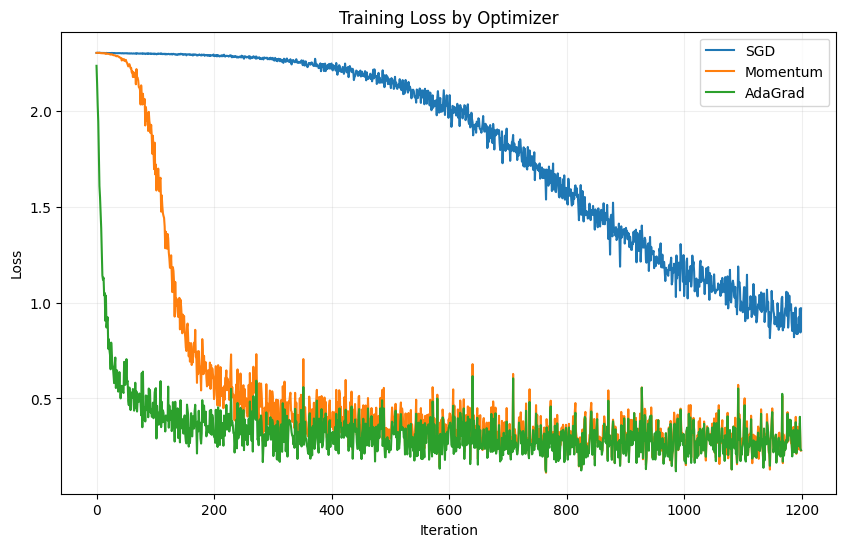

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(train_loss_list["sgd"], label="SGD", linewidth=1.5)
plt.plot(train_loss_list["momentum"], label="Momentum", linewidth=1.5)
plt.plot(train_loss_list["adagrad"], label="AdaGrad", linewidth=1.5)

plt.title("Training Loss by Optimizer")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(alpha=0.2)
plt.legend()
plt.show()


## 수치 바꿔보기

In [15]:
# batch_size: 100 -> 200
# iters_num: 1200 -> 600

iters_num = 600
train_size = x_train.shape[0]
batch_size = 200
learning_rate = 1e-2

optimizer_classes = {
    "sgd": SGD,
    "momentum": Momentum,
    "adagrad": AdaGrad,
}
train_loss_list = {name: [] for name in optimizer_classes}
iter_per_epoch = max(train_size // batch_size, 1)


for name, optimizer_class in optimizer_classes.items():
    print(f"\n====== Training with {name.upper()} optimizer ======")

    np.random.seed(SEED)
    current_network = TwoLayerNet(
        input_size=28 * 28,
        hidden_size=50,
        output_size=10,
    )

    if name == "momentum":
        current_optimizer = optimizer_class(
            lr=learning_rate,
            momentum=0.9,
        )
    else:
        current_optimizer = optimizer_class(lr=learning_rate)

    for iteration in range(iters_num):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        gradients = current_network.gradient(x_batch, t_batch)
        current_optimizer.update(current_network.params, gradients)

        loss = current_network.loss(x_batch, t_batch)
        train_loss_list[name].append(loss)

        if (iteration + 1) % iter_per_epoch == 0:
            epoch = (iteration + 1) // iter_per_epoch
            train_acc = current_network.accuracy(x_train, t_train)
            test_acc = current_network.accuracy(x_test, t_test)
            print(
                "Epoch {:d}, train: {:.4f}, test: {:.4f}".format(
                    epoch,
                    train_acc,
                    test_acc,
                )
            )



====== Training with SGD optimizer ======
Epoch 1, train: 0.2685, test: 0.2704
Epoch 2, train: 0.5382, test: 0.5435

====== Training with MOMENTUM optimizer ======
Epoch 1, train: 0.8748, test: 0.8794
Epoch 2, train: 0.9011, test: 0.9047

====== Training with ADAGRAD optimizer ======
Epoch 1, train: 0.9103, test: 0.9110
Epoch 2, train: 0.9202, test: 0.9208


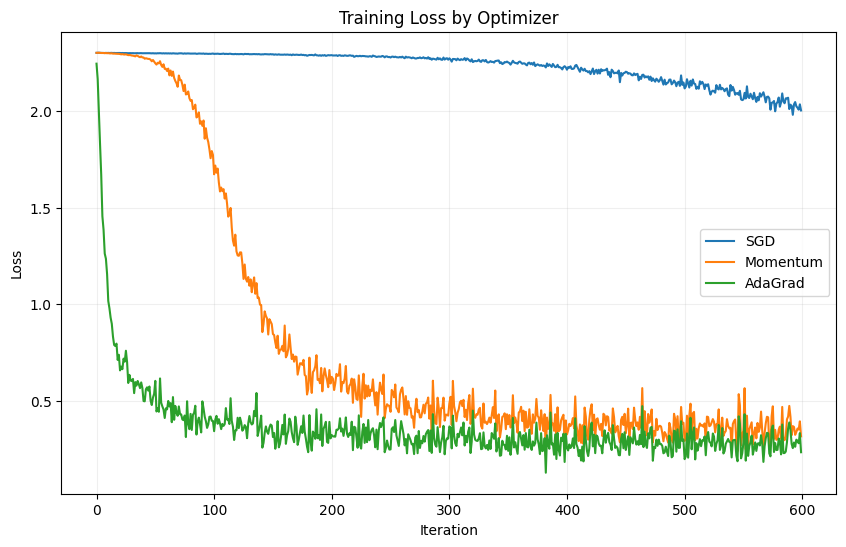

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(train_loss_list["sgd"], label="SGD", linewidth=1.5)
plt.plot(train_loss_list["momentum"], label="Momentum", linewidth=1.5)
plt.plot(train_loss_list["adagrad"], label="AdaGrad", linewidth=1.5)

plt.title("Training Loss by Optimizer")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(alpha=0.2)
plt.legend()
plt.show()


결과 관찰: \
SGD가 기본 설정보다 나빠짐(0.7811 -> 0.5382)\
Momentum, AdaGrad는 0.90 이상을 유지함

원인 설명:
1.  모델이 실제로 본 데이터 샘플의 총량은 같지만 파라미터를 업데이트한 횟수는 절반이 되었음. SGD는 '업데이트를 몇 번 했느냐'가 곧 '얼마나 이동했느냐'를 결정하기 때문에 업데이트 횟수가 줄면 그만큼 성능이 떨어짐. 반면 Momentum이나 Adagrad는 속도나 누적 기울기 덕분에 업데이트 횟수의 영향을 덜 받음.
2. 결론적으로, 같은 총 데이터량이라도 배치를 키우면 업데이트 횟수가 줄어 SGD 성능이 저하될 수 있음.

In [17]:
# learning_rate: 0.01 -> 0.1

iters_num = 1200
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

optimizer_classes = {
    "sgd": SGD,
    "momentum": Momentum,
    "adagrad": AdaGrad,
}
train_loss_list = {name: [] for name in optimizer_classes}
iter_per_epoch = max(train_size // batch_size, 1)


for name, optimizer_class in optimizer_classes.items():
    print(f"\n====== Training with {name.upper()} optimizer ======")

    np.random.seed(SEED)
    current_network = TwoLayerNet(
        input_size=28 * 28,
        hidden_size=50,
        output_size=10,
    )

    if name == "momentum":
        current_optimizer = optimizer_class(
            lr=learning_rate,
            momentum=0.9,
        )
    else:
        current_optimizer = optimizer_class(lr=learning_rate)

    for iteration in range(iters_num):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        gradients = current_network.gradient(x_batch, t_batch)
        current_optimizer.update(current_network.params, gradients)

        loss = current_network.loss(x_batch, t_batch)
        train_loss_list[name].append(loss)

        if (iteration + 1) % iter_per_epoch == 0:
            epoch = (iteration + 1) // iter_per_epoch
            train_acc = current_network.accuracy(x_train, t_train)
            test_acc = current_network.accuracy(x_test, t_test)
            print(
                "Epoch {:d}, train: {:.4f}, test: {:.4f}".format(
                    epoch,
                    train_acc,
                    test_acc,
                )
            )



====== Training with SGD optimizer ======
Epoch 1, train: 0.9038, test: 0.9075
Epoch 2, train: 0.9253, test: 0.9261

====== Training with MOMENTUM optimizer ======
Epoch 1, train: 0.9554, test: 0.9518
Epoch 2, train: 0.9650, test: 0.9593

====== Training with ADAGRAD optimizer ======
Epoch 1, train: 0.9449, test: 0.9428
Epoch 2, train: 0.9539, test: 0.9485


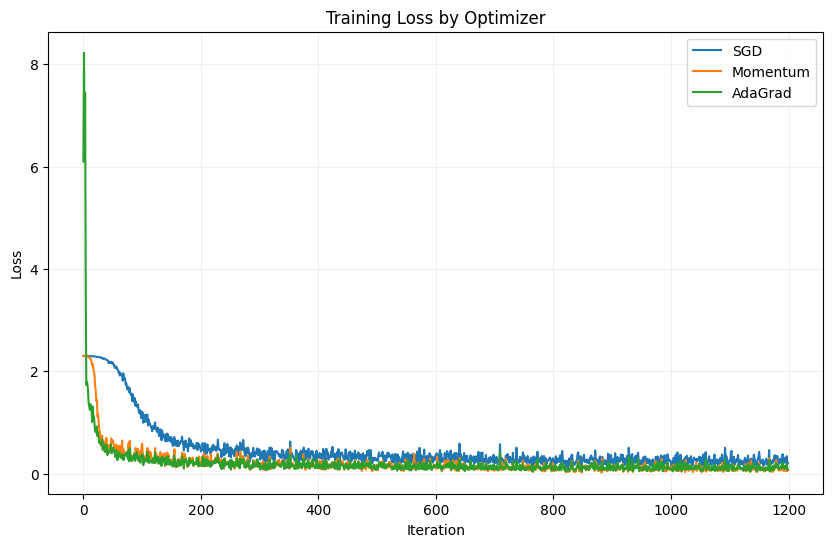

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(train_loss_list["sgd"], label="SGD", linewidth=1.5)
plt.plot(train_loss_list["momentum"], label="Momentum", linewidth=1.5)
plt.plot(train_loss_list["adagrad"], label="AdaGrad", linewidth=1.5)

plt.title("Training Loss by Optimizer")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(alpha=0.2)
plt.legend()
plt.show()


결과 관찰:\
SGD가 급격히 좋아짐(0.78 -> 0.93)\
Momentum, AdaGrad도 개선됨\
초반 loss가 8까지 올라갔다가 급락하는 모양이 보임

원인 설명:
1. 학습률이 크면 한번에 이동하는 거리가 커지는데, 초반에는 파라미터가 아직 최적점 근처가 아니기 때문에 큰 이동이 오히려 손실을 키우는 방향으로 갈 수 있음.
2. 학습률이 너무 크면 아예 발산하는 현상이 나타날 수 있음.

### 문제: 각 optimizer의 특징을 비교해주세요!
- SGD: 매 반복마다 그 순간의 기울기만 이용해 업데이트하는 방식이다. 이전 이동 방향에 대한 정보를 전혀 참고하지 않기 때문에 손실 표면이 평탄하거나 방향이 자주 바뀌는 구간에서 수렴이 느리게 나타난다. \
기본 실험 결과에서도 1200 iteration이 끝날 때까지 loss가 가장 높게 남아있었고, 2 epoch 후 정확도도 세 optimizer 중 가장 낮았다. 이를 통해 학습 속도가 가장 느리다는 것을 알 수 있다. \
다만 학습률을 0.1로 올렸을 때 정확도가 크게 개선되었다. 이는 SGD가 스텝 크기를 스스로 조절하는 메커니즘이 없어서 학습률 설정값에 따라 성능이 크게 좌우된다는 것을 보여준다. 반대로 배치를 키우고 iteration을 줄인 실험에서는 성능이 나빠졌는데, 이를 통해 SGD의 성능이 파라미터 업데이트 횟수에 크게 좌우된다는 것을 알 수 있다.
- momentum: 이전 업데이트 방향을 일정 비율만큼 유지하면서 새 기울기를 더해 이동하는 방식이다. 일관된 방향으로는 관성이 붙어 가속되고, 자주 바뀌는 방향으로는 진동이 서로 상쇄돼서 SGD보다 빠르고 안정적으로 수렴한다. 그래프에서 초반에는 SGD와 비슷하게 정체하다가 100~300 iteration 구간부터 loss가 급격히 떨어지는 현상이 나타난다. 최종적으로 SGD보다 훨씬 빠르게 낮은 loss에 도달했다.\
추가 실험에서도 기본 실험과 큰 차이가 없거나 성능이 좋아지는 것을 보면, 민감하게 반응하지 않고 비교적 안정적으로 좋은 성능을 유지한다는 것을 알 수 있다.
- adagrad: 파라미터마다 지금까지 누적된 기울기 제곱합을 이용해 학습률을 파라미터별로 자동 조정하는 방식이다. 자주 크게 업데이트된 파라미터는 학습률이 점점 작아지고, 자주 움직이지 않은 파라미터에 집중하게 되는 방식이다. 따라서 가장 빠르게 loss가 급락했음을 알 수 있다. \
학습률을 0.1로 키웠을 때 그래프 초반에 loss가 크게 올랐다가 급격히 떨어지는 형태가 나타나는데, 이는 adagrad가 거의 고정된 크기로 이동하기 때문에 초반에 일시적으로 예측이 틀어질 수 있다는 것을 보여준다. 다만 몇 스텝이 지나면 다시 안정을 되찾고, 최종적으로는 가장 빨리 낮은 loss에 도달한다.